In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PowerTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(tmin=-2, tmax=2, resample=None, fmin=0.1, fmax=None)
dataset = BNCI2014008()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.


<RawArray | 10 x 347704 (1358.2 s), ~26.5 MB, data loaded>

In [4]:
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-2.000 – 2.000 sec
Baseline,off


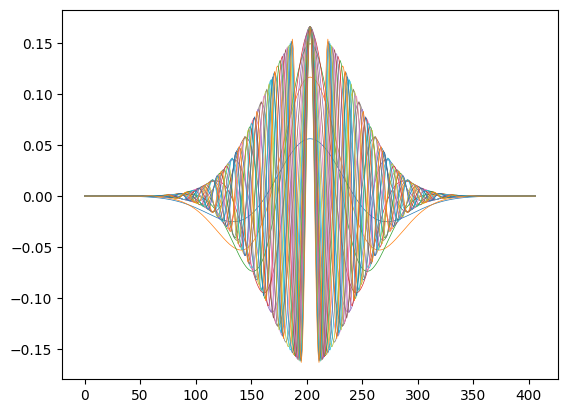

In [5]:
fmax = 16
sfreq=fmax*2
n_freqs=int(sfreq*0.7)
freqs = np.linspace(0.5, fmax, n_freqs)
n_cycles = freqs
wavelets = morlet(epochs.info['sfreq'],
                  freqs, n_cycles, zero_mean=True)
for i in range(n_freqs):
    plt.plot(np.real(wavelets[i]), linewidth=0.5)
plt.show()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:   19.5s remaining:   32.5s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:   25.7s remaining:   15.4s


Not setting metadata


[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:   27.3s finished
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot: ylabel='Density'>

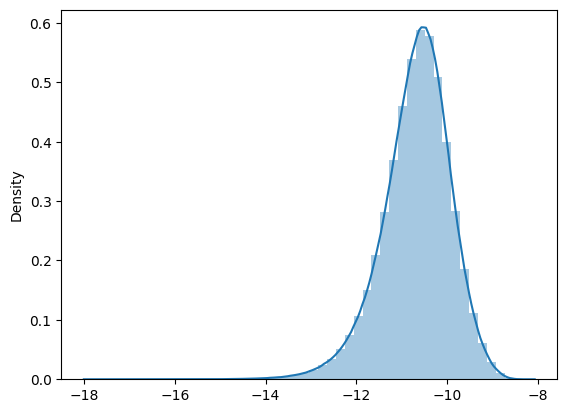

In [78]:
import seaborn as sns

epochs_tfr = tfr_morlet(epochs, freqs, n_cycles, return_itc=False, average=False,
                    output='power', verbose=True, n_jobs=-1, decim=int(epochs.info['sfreq']//sfreq))
epochs_tfr.data = np.log(np.sqrt(epochs_tfr.data))
epochs_tfr.crop(0, 0.8)


sns.distplot(epochs_tfr.data.flatten())

No baseline correction applied


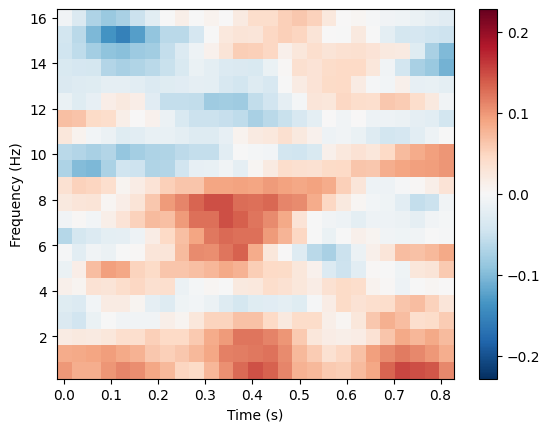

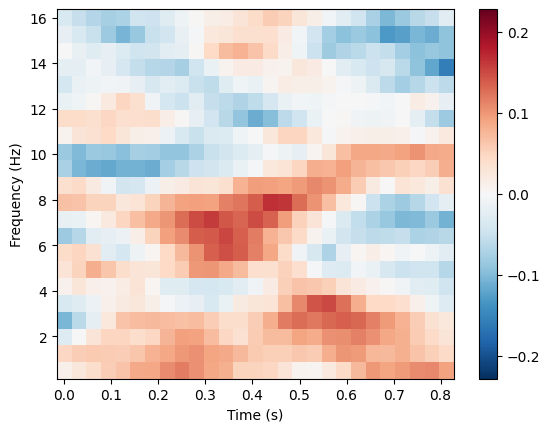

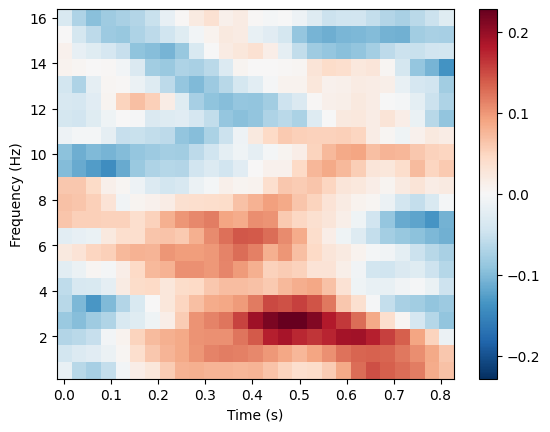

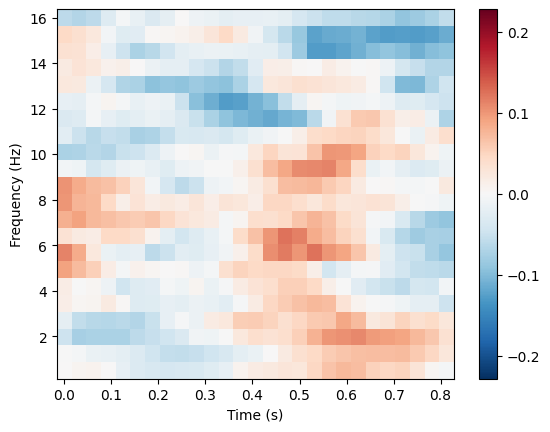

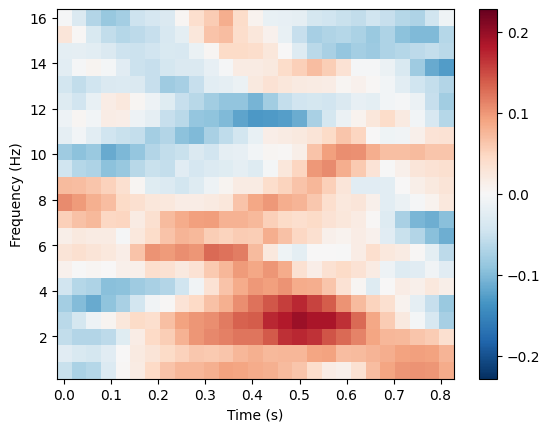

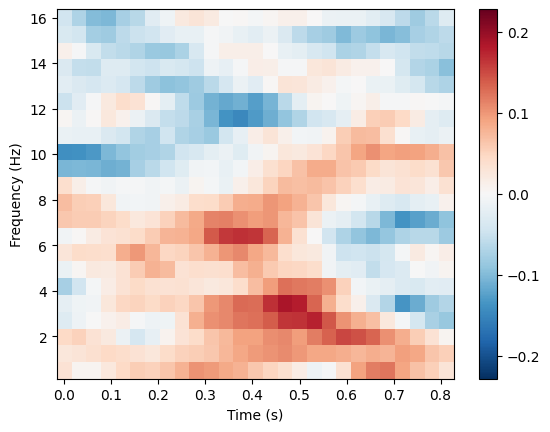

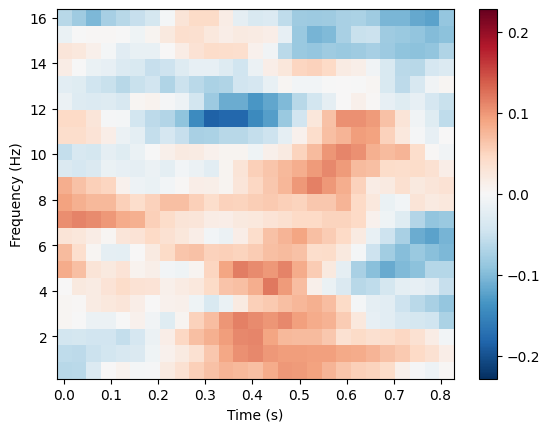

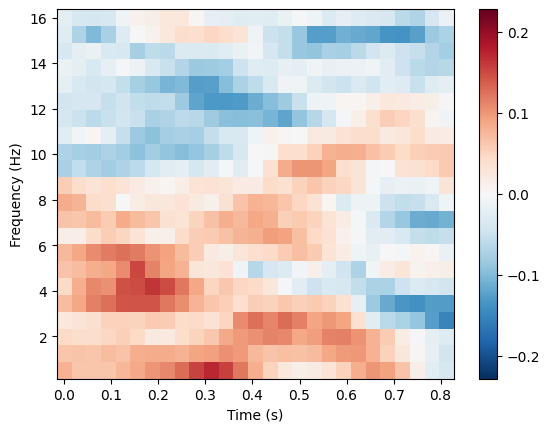

In [61]:
from mne import combine_evoked

target = epochs_tfr['Target'].average()
non_target = epochs_tfr['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_ = contrast.plot()

In [62]:
#epochs_data_flat = epochs.data.flatten()
#sns.jointplot(x=np.real(epochs_data_flat), y=np.imag(epochs_data_flat),kind="hex")

In [63]:
split = len(epochs)//2
epochs_train = epochs_tfr[:split]
epochs_test = epochs_tfr[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [64]:
import tensorly as tl
tl.set_backend('cupy')


In [65]:
import tensorly.decomposition
import tensorly.tenalg
X_train = tl.tensor(epochs_train.data)
y_train = labels_train
X_test = tl.tensor(epochs_test.data)
y_test = labels_test

In [79]:
hoda = HODA(max_iter=128, rank=X_train.shape[1:], tol=1e-6, initialize ='ones', verbose=True, 
            shrinkage=(0.01,0.2,0.2), toeplitz=(2,), solver='diff-svd')
hoda.fit(X_train,y_train)

[0/128]  shrinkage=0.0100  shrinkage=0.2000  shrinkage=0.2000  step=1.9673e+01
[1/128]  shrinkage=0.0100  shrinkage=0.2000  shrinkage=0.2000  step=5.2788e+00
[2/128]  shrinkage=0.0100  shrinkage=0.2000  shrinkage=0.2000  step=6.2944e-13


HODA(max_iter=128, rank=(8, 22, 27), shrinkage=(0.01, 0.2, 0.2),
     solver='diff-svd', toeplitz=(2,), tol=1e-06, verbose=True)

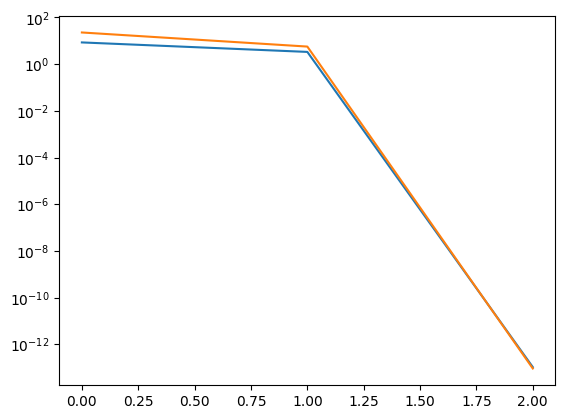

In [80]:
import cupy
plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

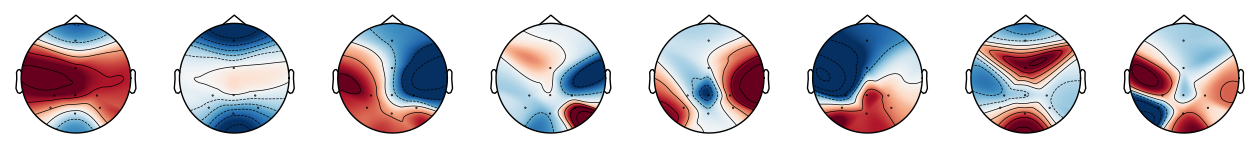

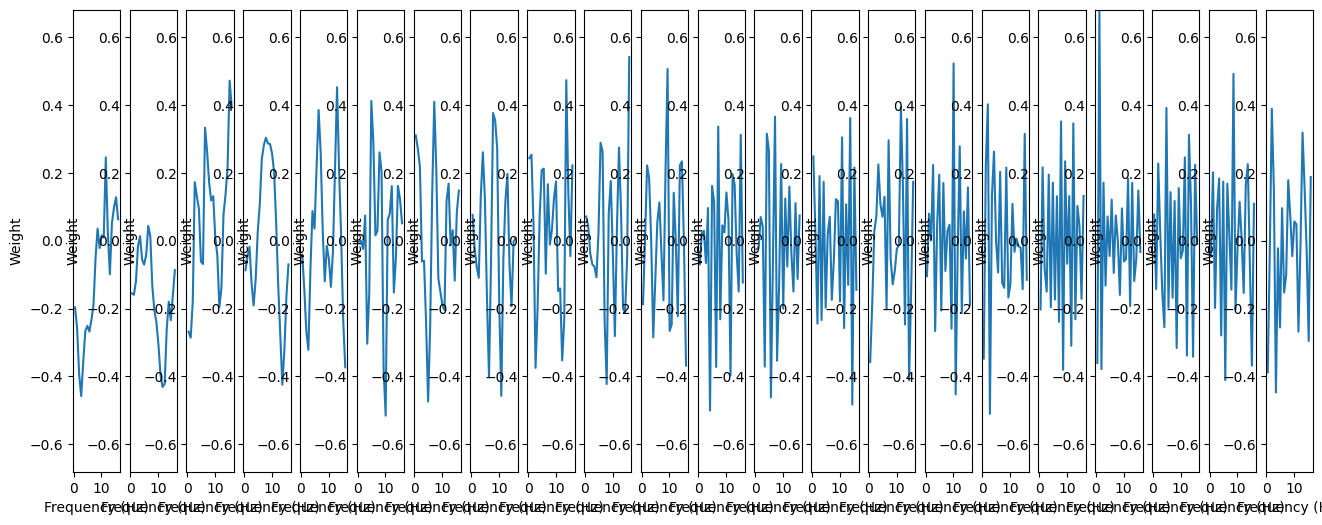

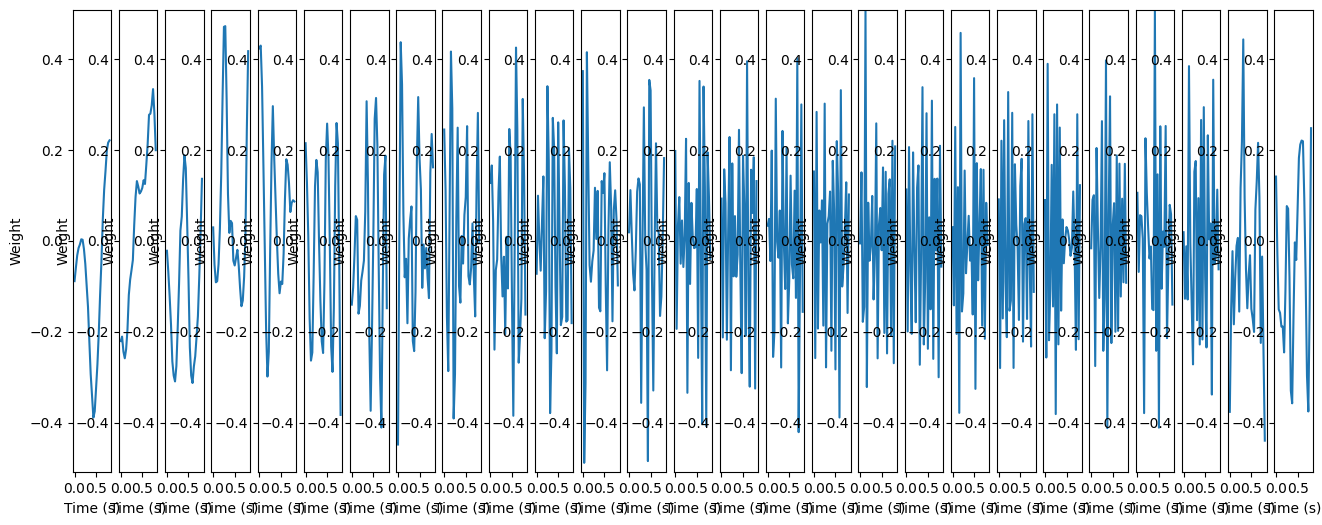

In [81]:
projs = [cupy.asnumpy(p) for k, p in enumerate(hoda.projs_)]


fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(projs[1]))
fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
for i in range(hoda.rank_[1]):
    w = projs[1][:,i]
    axs[i].plot(freqs, w)
    axs[i].set_xlabel('Frequency (Hz)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])
vmax = np.max(np.abs(projs[2]))
fig, axs = plt.subplots(1,hoda.rank_[2], figsize=(16,6))
for i in range(hoda.rank_[2]):
    w = projs[2][:,i]
    axs[i].plot(epochs_tfr.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])
plt.show()

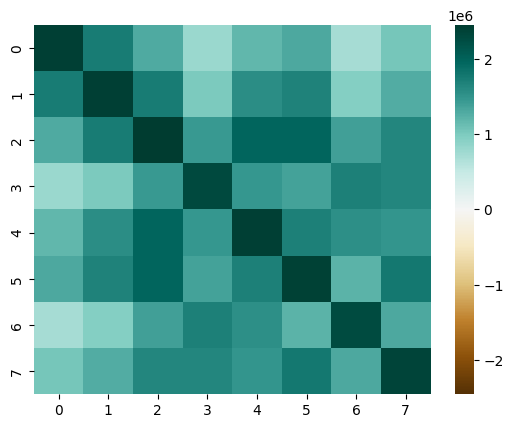

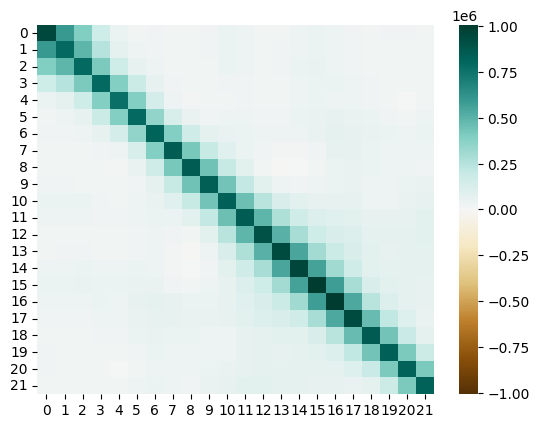

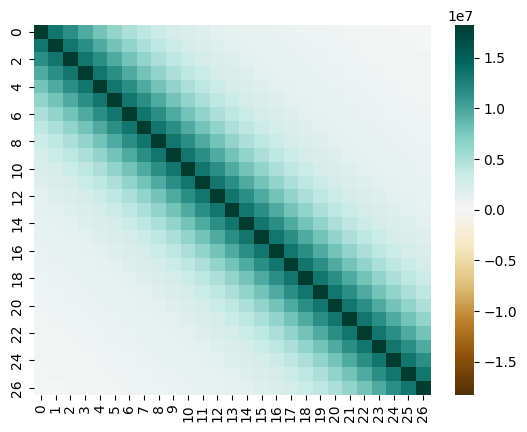

In [82]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

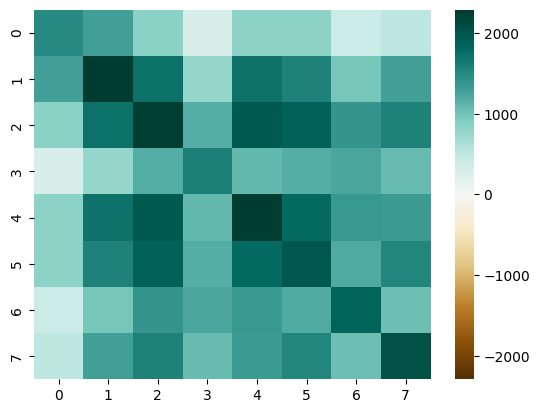

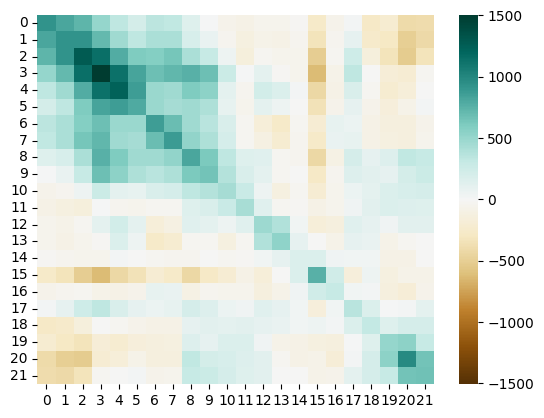

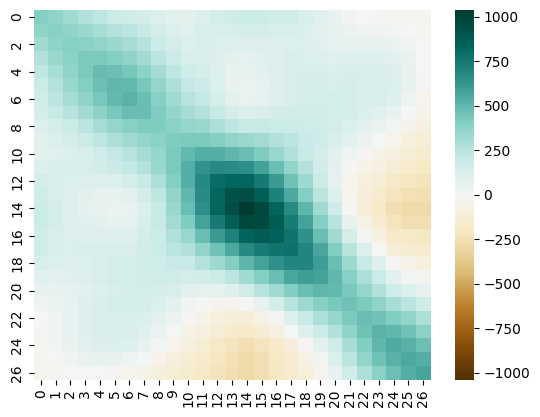

In [83]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

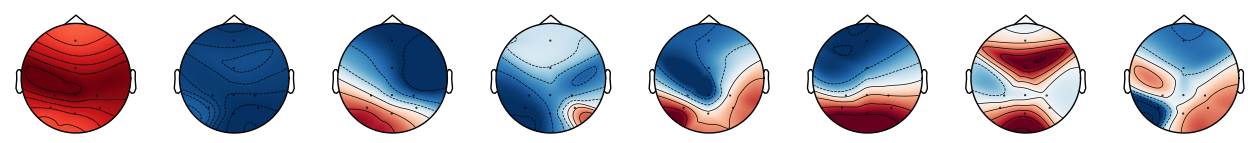

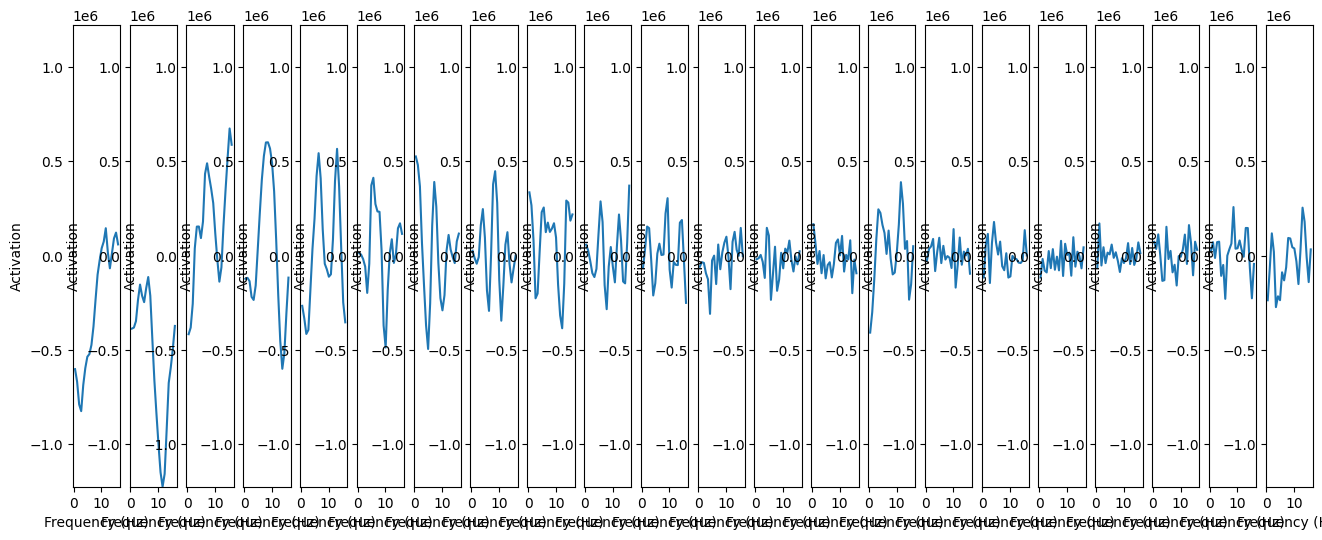

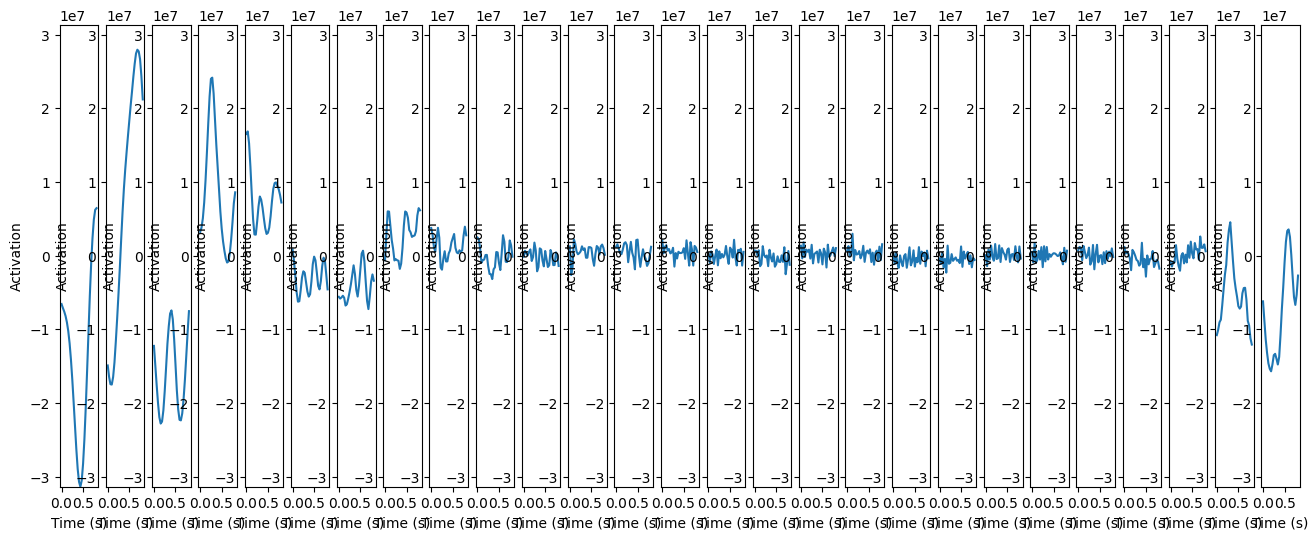

In [84]:
aps = [cupy.asnumpy(hoda.scatter_w_[k] @ p) for k,p in enumerate(hoda.projs_)]


fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[i], show=False)

fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank_[1]):
    w = aps[1][:,i]
    axs[i].plot(freqs, w)
    axs[i].set_xlabel('Frequency (Hz)')
    axs[i].set_ylabel('Activation')
    axs[i].set_ylim([-vmax, vmax])

fig, axs = plt.subplots(1,hoda.rank_[2], figsize=(16,6))
vmax = np.max(np.abs(aps[2]))
for i in range(hoda.rank_[2]):
    w = aps[2][:,i]
    axs[i].plot(epochs_tfr.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Activation')
    axs[i].set_ylim([-vmax, vmax])
plt.show()

In [85]:
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer

Xt_train = hoda.transform(X_train)
Xt_test = hoda.transform(X_test)

"""
fu = FeatureUnion([("real",FunctionTransformer(np.real)),
                   ("imag",FunctionTransformer(np.imag))])

Xt_train = fu.fit_transform(Xt_train)
Xt_test = fu.transform(Xt_test)
"""
Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

classifier = LogisticRegression(penalty='l1', solver='liblinear')
#classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

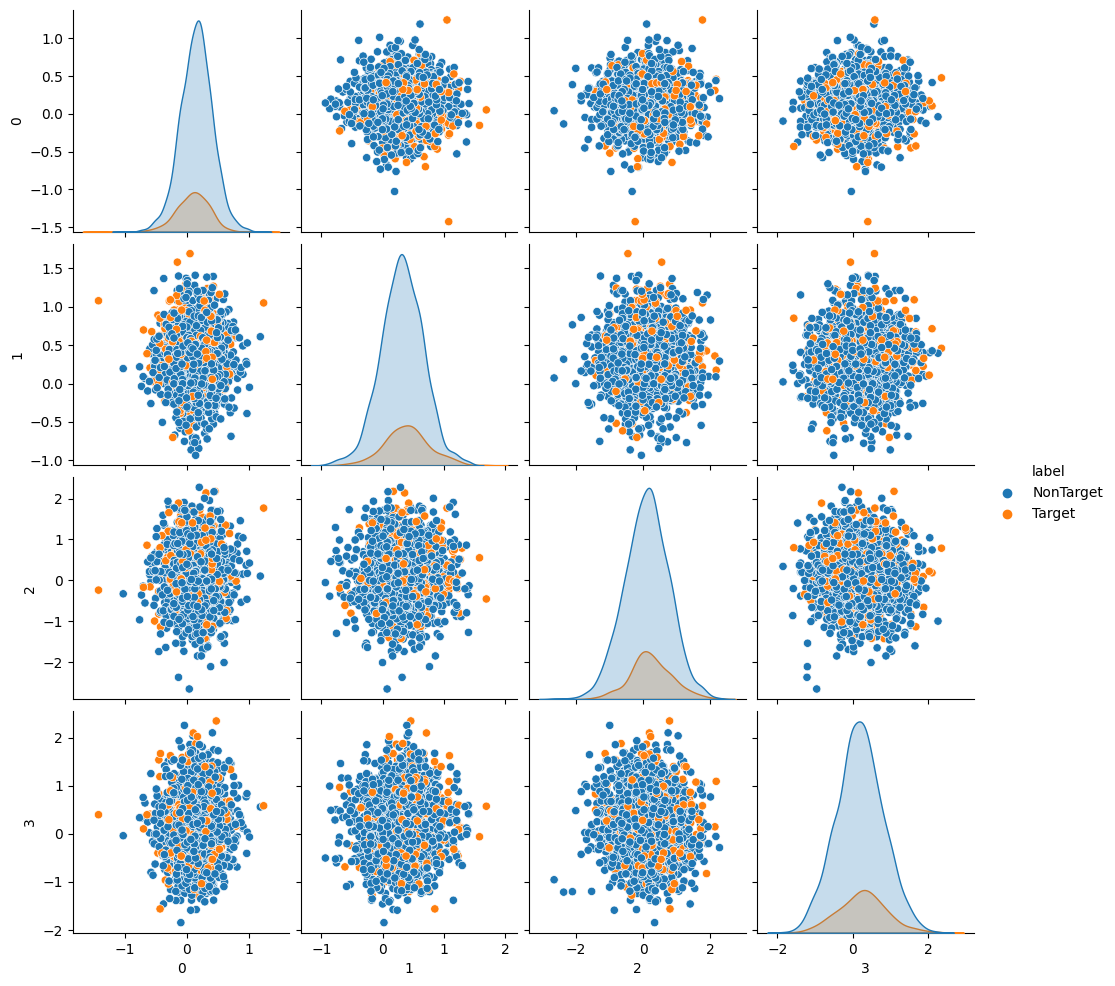

In [87]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
sns.pairplot(df_train, hue='label')
plt.show()

In [88]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

1.0

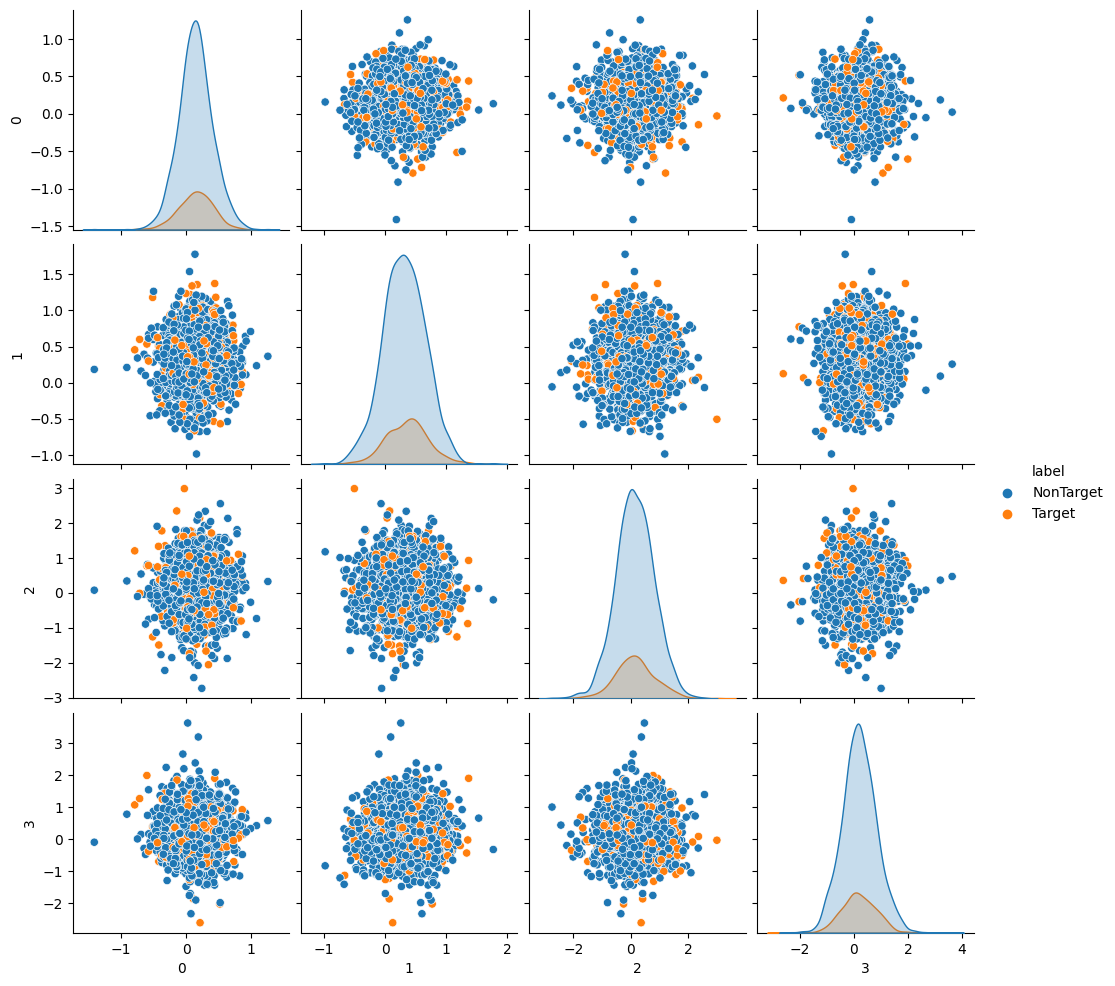

In [89]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
sns.pairplot(df_test, hue='label')
plt.show()

In [90]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.542261224489796